# Car Price Prediction with Machine Learning

## Oasis Infobyte Data Science Internship

### Task 3

### Objective

Build a regression model to predict the selling price of a used car using machine learning techniques.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Load Dataset

In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Understanding Dataset

In [3]:
df.shape

(301, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

## Data Cleaning

In [7]:
# Check Missing Values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(2)

In [10]:
# Remove Duplicates
df = df.drop_duplicates()

In [11]:
# Standardize Categorical Values
df["Fuel_Type"] = df["Fuel_Type"].str.title()

df["Selling_type"] = df["Selling_type"].str.title()

df["Transmission"] = df["Transmission"].str.title()

## Feature Engineering

In [12]:
#Create Car Age
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

In [17]:
#Extract Brand
df["Brand"] = df["Car_Name"].str.split().str[0]

In [18]:
#Check
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,swift


## EDA

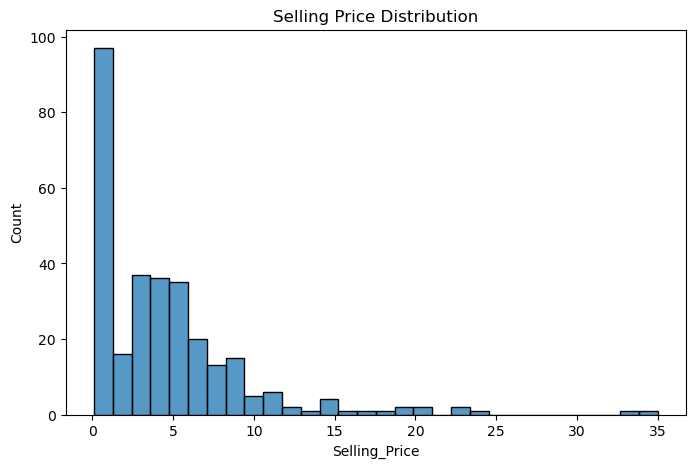

In [19]:
# Selling Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30)

plt.title("Selling Price Distribution")

plt.show()

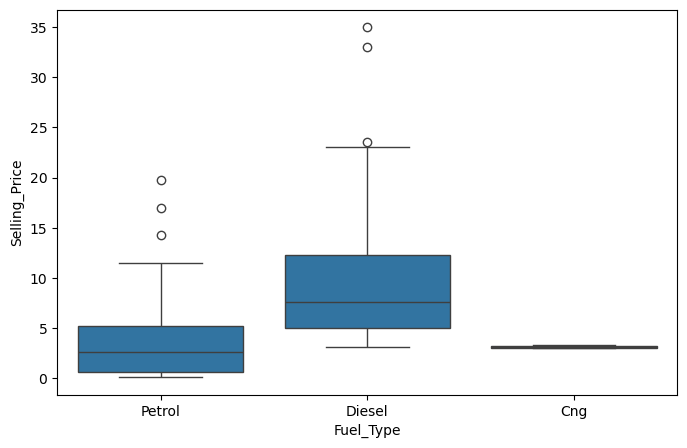

In [20]:
# Fuel Type vs Selling Price
plt.figure(figsize=(8,5))

sns.boxplot(x="Fuel_Type",
            y="Selling_Price",
            data=df)

plt.show()

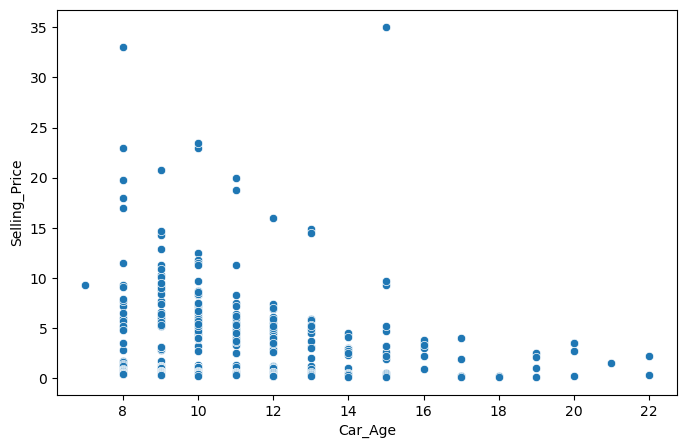

In [21]:
# Car Age vs Selling Price
plt.figure(figsize=(8,5))

sns.scatterplot(x="Car_Age",
                y="Selling_Price",
                data=df)

plt.show()

## Encoding

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Correlation Heatmap

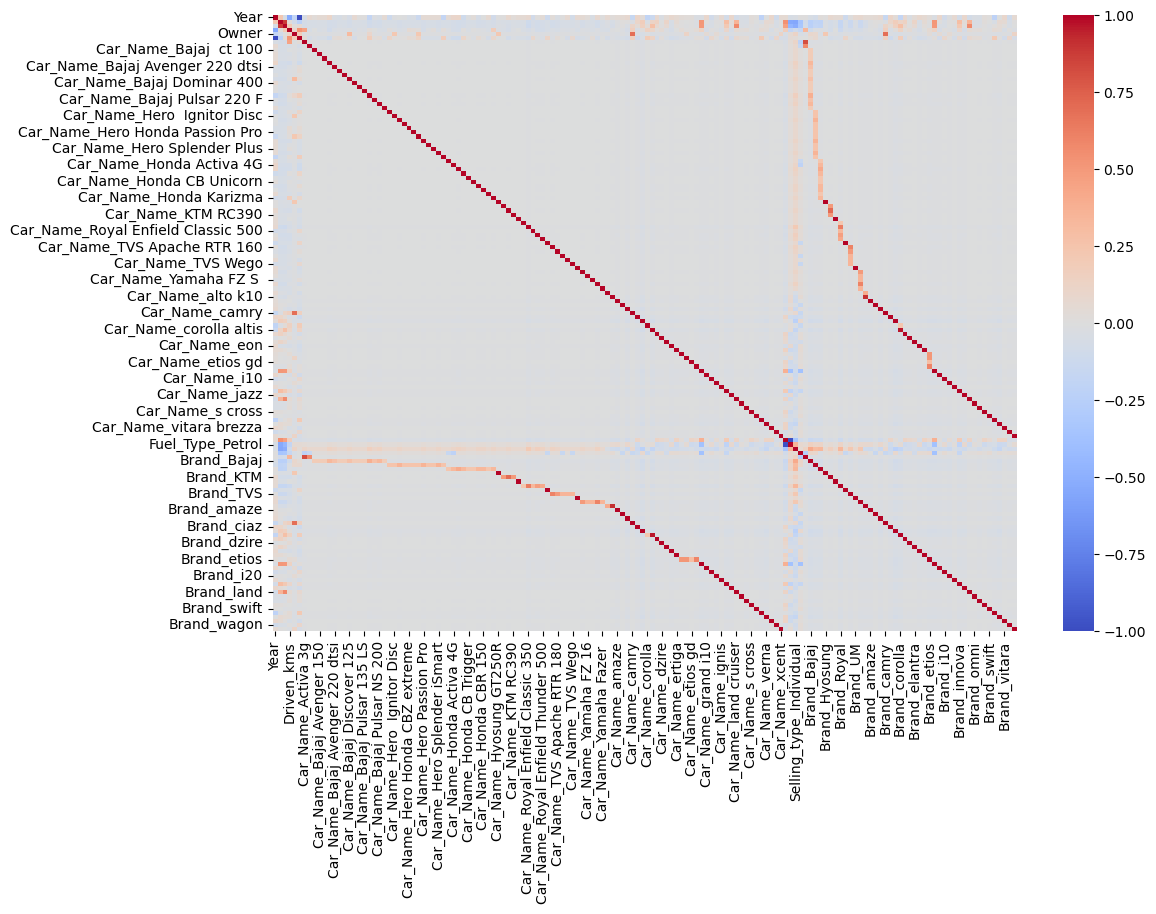

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(),
            cmap="coolwarm")

plt.show()

## Train-Test Split

In [24]:
X = df_encoded.drop("Selling_Price", axis=1)

y = df_encoded["Selling_Price"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model 1
# Linear Regression

In [26]:

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## Model 2
# Random Forest

In [29]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

## Model 3
# Gradient Boosting

In [32]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

## Evaluation

In [33]:
# Create a helper function:
def evaluate(actual, prediction):

    mae = mean_absolute_error(actual, prediction)

    rmse = np.sqrt(mean_squared_error(actual, prediction))

    r2 = r2_score(actual, prediction)

    print("MAE :", round(mae,3))

    print("RMSE :", round(rmse,3))

    print("R2 Score :", round(r2,3))

## Now evaluate all three models:

In [34]:
print("Linear Regression")

evaluate(y_test,pred_lr)

Linear Regression
MAE : 1.992
RMSE : 3.501
R2 Score : 0.524


In [35]:
print("Random Forest")

evaluate(y_test,pred_rf)

Random Forest
MAE : 1.383
RMSE : 3.389
R2 Score : 0.554


In [36]:
print("Gradient Boosting")

evaluate(y_test,pred_gb)

Gradient Boosting
MAE : 1.194
RMSE : 2.745
R2 Score : 0.708


Feature Importance

In [37]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

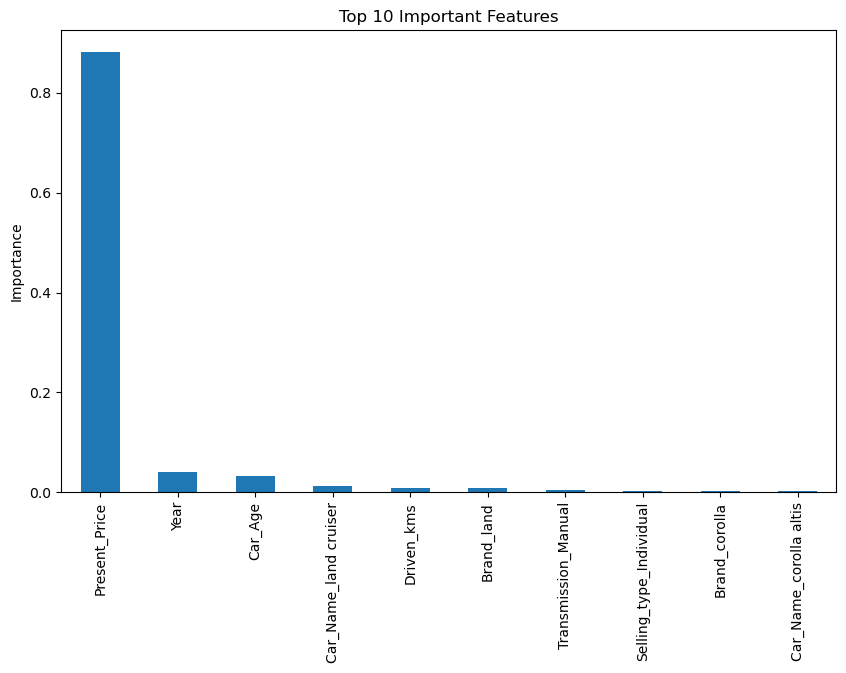

In [38]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.show()

## Conclusion

- Successfully cleaned the dataset.
- Created new features such as Car Age and Brand.
- Performed exploratory data analysis.
- Encoded categorical variables.
- Trained three regression models:
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor
- Compared the models using MAE, RMSE, and R² score.
- The model with the highest R² score and lowest MAE/RMSE was selected as the best-performing model.